# MOP 3231 · Task 2 — Decision Trees
SEED = 3194

In [36]:
import sys

import numpy
import pandas
import sklearn

print(sys.version.split()[0], numpy.__version__, pandas.__version__, sklearn.__version__)

3.12.5 2.0.2 2.3.3 1.6.1


In [37]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 3194

data = pd.read_csv("data/heart_disease.csv")
feature_names = [c for c in data.columns if c != "disease"]
X, y = data[feature_names].to_numpy(), data["disease"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
print(data.shape, round(y.mean(), 3), X_train.shape, X_test.shape)

(297, 14) 0.461 (207, 13) (90, 13)


## Part 1

In [38]:
from math import log2

# Q1: parent entropy (6 sick, 6 healthy)
H_parent = -(6/12)*log2(6/12) - (6/12)*log2(6/12)
print("H_parent =", H_parent)

# Q2: gains at the root
H_age1 = -(5/6)*log2(5/6) - (1/6)*log2(1/6)      # age_55_plus=1: 5 sick, 1 healthy
H_age0 = -(1/6)*log2(1/6) - (5/6)*log2(5/6)      # age_55_plus=0: 1 sick, 5 healthy
gain_age = H_parent - (6/12)*H_age1 - (6/12)*H_age0

H_ex1 = 0.0                                       # exercise_angina=1: 4 sick, 0 healthy
H_ex0 = -(2/8)*log2(2/8) - (6/8)*log2(6/8)        # exercise_angina=0: 2 sick, 6 healthy
gain_ex = H_parent - (4/12)*H_ex1 - (8/12)*H_ex0

H_m = -(3/6)*log2(3/6) - (3/6)*log2(3/6)          # male: both children 3 sick, 3 healthy
gain_male = H_parent - (6/12)*H_m - (6/12)*H_m

H_bp1 = -(4/6)*log2(4/6) - (2/6)*log2(2/6)        # high_bp=1: 4 sick, 2 healthy
H_bp0 = -(2/6)*log2(2/6) - (4/6)*log2(4/6)        # high_bp=0: 2 sick, 4 healthy
gain_bp = H_parent - (6/12)*H_bp1 - (6/12)*H_bp0

print("Root gains:")
for n, g in [("age_55_plus", gain_age), ("exercise_angina", gain_ex), ("male", gain_male), ("high_bp", gain_bp)]:
    print(f"  {n:16s} gain = {g:.4f}")

# Q3: inside branch exercise_angina=0 (8 rows: 2 sick, 6 healthy)
H_branch = -(2/8)*log2(2/8) - (6/8)*log2(6/8)
H_a1 = -(1/2)*log2(1/2) - (1/2)*log2(1/2)         # age=1: 1 sick, 1 healthy
H_a0 = -(1/6)*log2(1/6) - (5/6)*log2(5/6)         # age=0: 1 sick, 5 healthy
g_age_b = H_branch - (2/8)*H_a1 - (6/8)*H_a0
H_b0 = -(2/5)*log2(2/5) - (3/5)*log2(3/5)         # male=0: 2 sick, 3 healthy; male=1: 0 sick, 3 healthy
g_male_b = H_branch - (3/8)*0.0 - (5/8)*H_b0
H_c1 = -(1/3)*log2(1/3) - (2/3)*log2(2/3)         # high_bp=1: 1 sick, 2 healthy
H_c0 = -(1/5)*log2(1/5) - (4/5)*log2(4/5)         # high_bp=0: 1 sick, 4 healthy
g_bp_b = H_branch - (3/8)*H_c1 - (5/8)*H_c0
print(f"H_branch = {H_branch:.4f}")
for n, g in [("age_55_plus", g_age_b), ("male", g_male_b), ("high_bp", g_bp_b)]:
    print(f"  {n:12s} gain in branch = {g:.4f}")

H_parent = 1.0
Root gains:
  age_55_plus      gain = 0.3500
  exercise_angina  gain = 0.4591
  male             gain = 0.0000
  high_bp          gain = 0.0817
H_branch = 0.8113
  age_55_plus  gain in branch = 0.0738
  male         gain in branch = 0.2044
  high_bp      gain in branch = 0.0157


**Root:** `exercise_angina` has the highest gain (≈ 0.459), so the tree puts it at the root.

**One level down:** the impure branch is `exercise_angina = 0` (2 sick, 6 healthy). Inside it `male` has the highest gain (≈ 0.204), although its gain at the root was exactly 0.

**Why:** at the root `male` splits the patients into two groups that are both 50/50 sick, so it carries no information on its own. But the sick men all have exercise angina (p1–p3), while without exercise angina all 3 men are healthy. After the root split removes the angina patients, `male = 1` becomes a pure "healthy" group (3 of 3), and the gain appears. Information gain is computed per node, so a feature whose effect depends on another feature can look useless at the root and still be the best split below it.

## Part 2

In [39]:
import numpy as np


def entropy(y):
    """Entropy in bits of an array of integer class labels."""
    y = np.asarray(y)
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    p = counts[counts > 0] / len(y)
    return float(-np.sum(p * np.log2(p)))


def information_gain(y, left):
    """Entropy of y minus the size-weighted entropy of y[left] and y[~left]; left is a boolean mask."""
    y = np.asarray(y)
    left = np.asarray(left, dtype=bool)
    n = len(y)
    n_left = left.sum()
    n_right = n - n_left
    if n_left == 0 or n_right == 0:
        return 0.0
    return entropy(y) - (n_left / n) * entropy(y[left]) - (n_right / n) * entropy(y[~left])


def best_split(X, y, min_samples_leaf=1):
    """Return (feature_index, threshold, gain) of the best split, or None if no valid split exists."""
    X = np.asarray(X)
    y = np.asarray(y)
    best = None  # (gain, feature, threshold)
    for j in range(X.shape[1]):
        values = np.unique(X[:, j])
        if len(values) < 2:
            continue
        thresholds = (values[:-1] + values[1:]) / 2.0
        for t in thresholds:
            left = X[:, j] <= t
            n_left = left.sum()
            if n_left < min_samples_leaf or len(y) - n_left < min_samples_leaf:
                continue
            g = information_gain(y, left)
            # strictly greater: ties keep the earlier (lower feature, lower threshold) candidate
            if best is None or g > best[0] + 1e-12:
                best = (g, j, t)
    if best is None:
        return None
    return best[1], float(best[2]), float(best[0])


def _majority(y):
    """Majority class; a tie goes to the smaller label."""
    return int(np.argmax(np.bincount(y)))


def build_tree(X, y, max_depth=None, min_samples_leaf=1, depth=0):
    """Grow a tree recursively and return it as nested dicts (or any structure you like)."""
    X = np.asarray(X)
    y = np.asarray(y)
    if len(np.unique(y)) == 1 or (max_depth is not None and depth == max_depth):
        return {"leaf": True, "pred": _majority(y), "n": len(y)}
    split = best_split(X, y, min_samples_leaf)
    if split is None:
        return {"leaf": True, "pred": _majority(y), "n": len(y)}
    j, t, g = split
    left = X[:, j] <= t
    return {
        "leaf": False, "feature": j, "threshold": t, "n": len(y),
        "left": build_tree(X[left], y[left], max_depth, min_samples_leaf, depth + 1),
        "right": build_tree(X[~left], y[~left], max_depth, min_samples_leaf, depth + 1),
    }


def _predict_one(tree, x):
    while not tree["leaf"]:
        tree = tree["left"] if x[tree["feature"]] <= tree["threshold"] else tree["right"]
    return tree["pred"]


def predict_tree(tree, X):
    """Return one predicted label per row of X."""
    X = np.asarray(X)
    return np.array([_predict_one(tree, x) for x in X])


def count_leaves(tree):
    return 1 if tree["leaf"] else count_leaves(tree["left"]) + count_leaves(tree["right"])

In [40]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

toy = pd.DataFrame({
    "age_55_plus": [1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0],
    "exercise_angina": [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    "male": [1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
    "high_bp": [1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
    "disease": [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
})

# Q1: reproduce Part 1 values on the toy table
y_toy = toy["disease"].to_numpy()
print("entropy(toy):", entropy(y_toy))
for f in ["age_55_plus", "exercise_angina", "male", "high_bp"]:
    print(f"{f:16s} gain = {information_gain(y_toy, toy[f].to_numpy() == 0):.4f}")

# Q2: best_split vs sklearn depth-1 on the training split
mine = best_split(X_train, y_train)
ref = DecisionTreeClassifier(criterion="entropy", max_depth=1, random_state=SEED).fit(X_train, y_train)
print("mine:   ", feature_names[mine[0]], mine[1], round(mine[2], 4))
print("sklearn:", feature_names[ref.tree_.feature[0]], ref.tree_.threshold[0])

entropy(toy): 1.0
age_55_plus      gain = 0.3500
exercise_angina  gain = 0.4591
male             gain = 0.0000
high_bp          gain = 0.0817
mine:    ca 0.5 0.2509
sklearn: ca 0.5


1. `entropy` and `information_gain` reproduce the hand values of Part 1: entropy 1.0 and gains 0.3500, 0.4591, 0.0000, 0.0817.
2. My `best_split` on `X_train, y_train` chooses `ca <= 0.5` (gain 0.2509), the same feature and threshold as scikit-learn's depth-1 tree.

In [41]:
import time

depths = [1, 2, 3, 4, 5, None]
rows = []
t0 = time.time()
for d in depths:
    mine_tree = build_tree(X_train, y_train, max_depth=d)
    ref_tree = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED).fit(X_train, y_train)
    p_mine = predict_tree(mine_tree, X_test)
    p_ref = ref_tree.predict(X_test)
    rows.append({
        "max_depth": "None" if d is None else d,
        "leaves_mine": count_leaves(mine_tree),
        "leaves_sklearn": ref_tree.get_n_leaves(),
        "test_agreement": float((p_mine == p_ref).mean()),
    })
agreement = pd.DataFrame(rows)
print(agreement.to_string(index=False))
print(f"time: {time.time() - t0:.1f}s")

max_depth  leaves_mine  leaves_sklearn  test_agreement
        1            2               2        1.000000
        2            4               4        1.000000
        3            8               8        1.000000
        4           15              15        1.000000
        5           21              21        0.977778
     None           32              32        0.966667
time: 0.2s


In [42]:
def compare_trees(my, sk, node, Xn, yn, path="root"):
    """Walk both trees together and report the first node where the chosen split differs."""
    sk_leaf = sk.children_left[node] == -1
    if my["leaf"] or sk_leaf:
        if my["leaf"] != sk_leaf:
            print(f"{path}: n={len(yn)}, one tree stops here and the other splits")
        return
    jm, tm = my["feature"], my["threshold"]
    js, ts = int(sk.feature[node]), float(sk.threshold[node])
    if jm != js or abs(tm - ts) > 1e-4 * max(1.0, abs(tm)):
        gm = information_gain(yn, Xn[:, jm] <= tm)
        gs = information_gain(yn, Xn[:, js] <= ts)
        print(f"{path}: n={len(yn)}")
        print(f"  mine:    {feature_names[jm]} <= {tm:.4f}, gain = {gm:.6f}")
        print(f"  sklearn: {feature_names[js]} <= {ts:.4f}, gain = {gs:.6f}")
        print(f"  gain difference = {abs(gm - gs):.2e}")
        return
    mask = Xn[:, jm] <= tm
    compare_trees(my["left"], sk, sk.children_left[node], Xn[mask], yn[mask], path + " -> L")
    compare_trees(my["right"], sk, sk.children_right[node], Xn[~mask], yn[~mask], path + " -> R")

for d in [5, None]:
    print(f"--- max_depth = {d} ---")
    mt = build_tree(X_train, y_train, max_depth=d)
    rt = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED).fit(X_train, y_train)
    compare_trees(mt, rt.tree_, 0, X_train, y_train)

--- max_depth = 5 ---
root -> L -> R -> L -> R: n=12
  mine:    cp <= 1.5000, gain = 0.247150
  sklearn: chol <= 275.5000, gain = 0.247150
  gain difference = 0.00e+00
root -> L -> R -> R -> R: n=5
  mine:    age <= 59.0000, gain = 0.321928
  sklearn: sex <= 0.5000, gain = 0.321928
  gain difference = 0.00e+00
root -> R -> L -> R -> L: n=4
  mine:    age <= 55.5000, gain = 0.311278
  sklearn: ca <= 1.5000, gain = 0.311278
  gain difference = 0.00e+00
--- max_depth = None ---
root -> L -> L -> L -> L -> L -> R: n=3
  mine:    trestbps <= 106.0000, gain = 0.918296
  sklearn: restecg <= 1.0000, gain = 0.918296
  gain difference = 0.00e+00
root -> L -> R -> L -> R: n=12
  mine:    cp <= 1.5000, gain = 0.247150
  sklearn: chol <= 275.5000, gain = 0.247150
  gain difference = 0.00e+00
root -> L -> R -> R -> R: n=5
  mine:    age <= 59.0000, gain = 0.321928
  sklearn: chol <= 214.0000, gain = 0.321928
  gain difference = 0.00e+00
root -> R -> L -> R -> L: n=4
  mine:    age <= 55.5000, gain =

**Agreement with scikit-learn.** For depths 1-4 my tree and scikit-learn's predict the same label on 100% of the test rows. At depth 5 the agreement is 97.8% (2 of 90 rows) and with unlimited depth 96.7% (3 of 90 rows). The number of leaves is identical in every case.

**Cause.** Walking both trees together shows that they first differ at small nodes (n = 3 to 12 training rows). At every such node the information gain of my split and of scikit-learn's split is exactly equal (difference 0.00e+00), i.e. it is a tie between several features that separate the few patients in the node in the same way. My implementation resolves ties by the rule from the task (lower feature index, then lower threshold). scikit-learn visits the features in a random order controlled by `random_state` and keeps the first best one, so on a tie it can pick another, equally good, feature. The trees are therefore equivalent in training quality, but the different split in one small node changes the prediction for the few test rows that fall into it.

## Part 3

In [43]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

depth_grid = [1, 2, 3, 4, 5, 6, 8, 10, None]
rows = []
for d in depth_grid:
    model = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED)
    s = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy", return_train_score=True)
    leaves = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED).fit(X_train, y_train).get_n_leaves()
    rows.append({
        "max_depth": "None" if d is None else d,
        "leaves": leaves,
        "train_acc": s["train_score"].mean(),
        "cv_acc": s["test_score"].mean(),
        "cv_std": s["test_score"].std(),
    })
depth_table = pd.DataFrame(rows)
print(depth_table.round(4).to_string(index=False))

max_depth  leaves  train_acc  cv_acc  cv_std
        1       2     0.7874  0.7876  0.0411
        2       4     0.8225  0.8066  0.0168
        3       8     0.8913  0.8453  0.0470
        4      15     0.9263  0.8210  0.0338
        5      21     0.9577  0.8163  0.0366
        6      27     0.9783  0.8164  0.0329
        8      31     0.9976  0.7871  0.0402
       10      32     1.0000  0.7871  0.0402
     None      32     1.0000  0.7871  0.0402


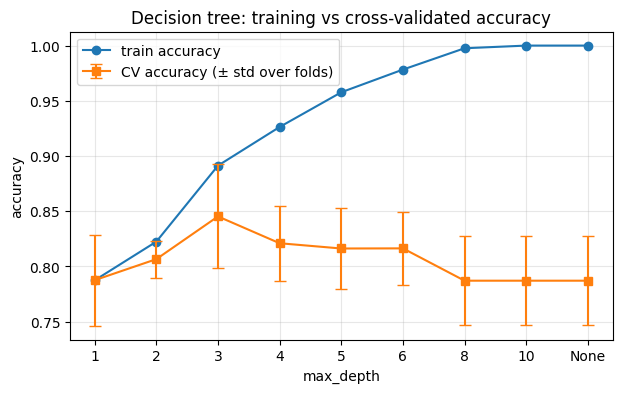

In [44]:
import matplotlib.pyplot as plt

x_pos = list(range(len(depth_table)))
labels = depth_table["max_depth"].astype(str).tolist()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_pos, depth_table["train_acc"], "o-", label="train accuracy")
ax.errorbar(x_pos, depth_table["cv_acc"], yerr=depth_table["cv_std"], fmt="s-", capsize=4, label="CV accuracy (± std over folds)")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title("Decision tree: training vs cross-validated accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [45]:
best = depth_table.loc[depth_table["cv_acc"].idxmax()]
se = best["cv_std"] / np.sqrt(5)
threshold = best["cv_acc"] - se
eligible = depth_table[depth_table["cv_acc"] >= threshold]
chosen = eligible.sort_values("leaves").iloc[0]
chosen_depth = None if chosen["max_depth"] == "None" else int(chosen["max_depth"])
print(f"best mean = {best['cv_acc']:.4f}, std = {best['cv_std']:.4f}, SE = {se:.4f}, threshold = {threshold:.4f}")
print(eligible[["max_depth", "leaves", "cv_acc", "cv_std"]].round(4).to_string(index=False))
print("chosen max_depth:", chosen_depth)

best mean = 0.8453, std = 0.0470, SE = 0.0210, threshold = 0.8243
max_depth  leaves  cv_acc  cv_std
        3       8  0.8453   0.047
chosen max_depth: 3


**Selection rule (one-standard-error rule).** Take the depth with the highest mean CV accuracy, compute its standard error over the 5 folds (std / √5), and choose the simplest tree (fewest leaves) whose mean CV accuracy is at least `best_mean − SE`. Here best mean = 0.8453, std = 0.0470, SE = 0.0210, threshold = 0.8243; only max_depth = 3 qualifies, so the chosen depth is 3.

**Is it clearly better than its neighbours?** Only partly. It beats depth ≥ 8 by about 0.058, more than one fold-std, but it is ahead of depth 2 by 0.039 and of depth 4 by 0.024, both smaller than its fold-std (0.047). So depth 3 is a reasonable choice, but depths 2-4 cannot be told apart with confidence.

**Train vs CV gap at max_depth=None.** Train accuracy is 1.000 and CV accuracy 0.787: the unlimited tree memorises the training set (over-fitting) and loses about 21 points on unseen folds.

In [46]:
leaf_grid = [1, 2, 5, 10, 20, 40]
rows = []
for m in leaf_grid:
    model = DecisionTreeClassifier(criterion="entropy", max_depth=None, min_samples_leaf=m, random_state=SEED)
    s = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy", return_train_score=True)
    leaves = DecisionTreeClassifier(criterion="entropy", max_depth=None, min_samples_leaf=m, random_state=SEED).fit(X_train, y_train).get_n_leaves()
    rows.append({
        "min_samples_leaf": m,
        "leaves": leaves,
        "train_acc": s["train_score"].mean(),
        "cv_acc": s["test_score"].mean(),
        "cv_std": s["test_score"].std(),
    })
leaf_table = pd.DataFrame(rows)
print(leaf_table.round(4).to_string(index=False))

 min_samples_leaf  leaves  train_acc  cv_acc  cv_std
                1      32     1.0000  0.7871  0.0402
                2      28     0.9626  0.7775  0.0504
                5      18     0.9203  0.8405  0.0558
               10      10     0.8817  0.8353  0.0503
               20       7     0.8213  0.8213  0.0193
               40       5     0.7874  0.7876  0.0411


**Two brakes compared.** Limiting depth and limiting leaf size both reduce over-fitting, and at their best they perform about equally: max_depth=3 gives CV accuracy 0.8453 ± 0.047 with 8 leaves, min_samples_leaf=5 gives 0.8405 ± 0.056 with 18 leaves. The 0.005 difference is far smaller than the fold spread, so I cannot tell them apart. They act differently, though: max_depth caps the tree uniformly, while min_samples_leaf only stops splits that would create tiny leaves, so the tree can still grow deep where there is plenty of data. Both fail at the extreme (min_samples_leaf=40 underfits: train 0.787 = CV 0.788, as for max_depth=1).

In [47]:
final_tree = DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED).fit(X_train, y_train)
test_acc = final_tree.score(X_test, y_test)
test_se = np.sqrt(test_acc * (1 - test_acc) / len(y_test))
print(f"test accuracy = {test_acc:.4f}, standard error = {test_se:.4f}, n = {len(y_test)}")

test accuracy = 0.7556, standard error = 0.0453, n = 90


**Test accuracy (evaluated once).** The depth-3 tree reaches 0.7556 on the 90 test rows, standard error sqrt(0.7556·0.2444/90) = 0.0453. This is about 0.09 below its CV accuracy (0.8453). Two reasons: the depth was chosen as the maximum over nine CV scores, so the CV figure is optimistically biased, and with n = 90 the test estimate itself is noisy (±0.045). The gap is roughly two standard errors, so I do not read it as a failure of the method, and I keep max_depth = 3 without re-tuning on the test set.

## Part 4

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "tree depth=3": DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED),
    "tree unlimited": DecisionTreeClassifier(criterion="entropy", max_depth=None, random_state=SEED),
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
}
rows = []
for name, m in models.items():
    s = cross_validate(m, X_train, y_train, cv=cv, scoring=("accuracy", "f1"))
    rows.append({
        "model": name,
        "cv_acc_mean": s["test_accuracy"].mean(),
        "cv_acc_std": s["test_accuracy"].std(),
        "cv_f1_mean": s["test_f1"].mean(),
    })
cv_table = pd.DataFrame(rows)
print(cv_table.round(4).to_string(index=False))

              model  cv_acc_mean  cv_acc_std  cv_f1_mean
       tree depth=3       0.8453      0.0470      0.8216
     tree unlimited       0.7871      0.0402      0.7738
logistic regression       0.8071      0.0321      0.7831


In [49]:
scaler = StandardScaler().fit(X_train)
t_raw = DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED).fit(X_train, y_train)
t_scaled = DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED).fit(scaler.transform(X_train), y_train)
agree = (t_raw.predict(X_test) == t_scaled.predict(scaler.transform(X_test))).mean()
print("agreement:", agree)

agreement: 1.0


In [50]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

tree_final = DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED).fit(X_train, y_train)
logreg_final = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_train, y_train)
for name, m in [("tree depth=3", tree_final), ("logistic regression", logreg_final)]:
    p = m.predict(X_test)
    print(name, "acc =", round(accuracy_score(y_test, p), 4), "F1 =", round(f1_score(y_test, p), 4))
    print(confusion_matrix(y_test, p))

tree depth=3 acc = 0.7556 F1 = 0.7442
[[36 12]
 [10 32]]
logistic regression acc = 0.8111 F1 = 0.8046
[[38 10]
 [ 7 35]]


**Does a tree need scaling?** No. The depth-3 tree fitted on raw and on standardized features gives identical predictions on all 90 test rows (agreement 1.0). A split only depends on the ordering of the values of one feature, and standardization is an increasing linear map per feature, so it keeps the ordering and produces the same partitions; only the numeric thresholds change. Logistic regression, in contrast, is sensitive to feature scale through regularization and the optimizer, hence the scaler in its pipeline.

**Conclusion.** In cross-validation the depth-3 tree (0.845 ± 0.047) is ahead of logistic regression (0.807 ± 0.032), but on the test set the order reverses (logistic regression 0.811, SE 0.041; tree 0.756, SE 0.045). Both gaps (0.038 in CV, 0.056 on test, i.e. 5 of 90 rows) are smaller than the fold spread and about one standard error, so I cannot declare a winner; the CV advantage of the tree is also optimistic because its depth was selected on the same folds. The unlimited tree (0.787) is not distinguishable from logistic regression either, and the only difference I trust is that the depth-3 tree is better than the unlimited one in CV (by 0.058, more than one fold-std). If one model must be used, I would take logistic regression: its fold spread is smaller, its test accuracy is higher, and it has no tuned hyperparameter that could inflate its estimate. If a human-readable rule set matters more, the depth-3 tree is an acceptable alternative at the cost of an accuracy that is statistically unclear.

## Part 5

In [51]:
from sklearn.tree import export_text

shallow = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED).fit(X_train, y_train)
print(export_text(shallow, feature_names=feature_names))
ranked = sorted(zip(shallow.feature_importances_, feature_names), reverse=True)
print([(name, round(float(imp), 3)) for imp, name in ranked[:5]])

t = shallow.tree_
def walk(node=0, conds=()):
    if t.children_left[node] == -1:
        v = t.value[node][0]
        counts = np.round(v / v.sum() * t.n_node_samples[node]).astype(int)
        print(f"{' AND '.join(conds)} -> class {int(np.argmax(v))}, "
              f"n={t.n_node_samples[node]}, [no disease, disease] = {counts.tolist()}")
        return
    f, thr = feature_names[t.feature[node]], t.threshold[node]
    walk(t.children_left[node], conds + (f"{f} <= {thr:.2f}",))
    walk(t.children_right[node], conds + (f"{f} > {thr:.2f}",))
walk()

|--- ca <= 0.50
|   |--- thal <= 6.50
|   |   |--- age <= 57.50
|   |   |   |--- class: 0
|   |   |--- age >  57.50
|   |   |   |--- class: 0
|   |--- thal >  6.50
|   |   |--- oldpeak <= 0.70
|   |   |   |--- class: 0
|   |   |--- oldpeak >  0.70
|   |   |   |--- class: 1
|--- ca >  0.50
|   |--- cp <= 3.50
|   |   |--- slope <= 1.50
|   |   |   |--- class: 0
|   |   |--- slope >  1.50
|   |   |   |--- class: 1
|   |--- cp >  3.50
|   |   |--- thalach <= 106.50
|   |   |   |--- class: 1
|   |   |--- thalach >  106.50
|   |   |   |--- class: 1

[('ca', 0.423), ('thal', 0.191), ('cp', 0.155), ('oldpeak', 0.099), ('age', 0.064)]
ca <= 0.50 AND thal <= 6.50 AND age <= 57.50 -> class 0, n=67, [no disease, disease] = [65, 2]
ca <= 0.50 AND thal <= 6.50 AND age > 57.50 -> class 0, n=26, [no disease, disease] = [19, 7]
ca <= 0.50 AND thal > 6.50 AND oldpeak <= 0.70 -> class 0, n=14, [no disease, disease] = [11, 3]
ca <= 0.50 AND thal > 6.50 AND oldpeak > 0.70 -> class 1, n=19, [no disease, di

**Two rules (depth-3 tree, training patients).**

- *Predicts disease:* if at least one major vessel is coloured by fluoroscopy (`ca > 0.5`), **and** the chest pain is asymptomatic (`cp > 3.5`, i.e. type 4), **and** the maximum heart rate is above 106.5 (`thalach > 106.5`), then the tree predicts disease. 43 training patients reach this leaf, and all 43 have the disease.
- *Predicts no disease:* if no vessel is coloured (`ca <= 0.5`), **and** the thal result is normal or a fixed defect (`thal <= 6.5`, i.e. 3 or 6), **and** the age is at most 57.5, then the tree predicts no disease. 67 training patients reach this leaf: 65 are healthy and 2 have the disease.

**Importances.** The five most important features of the depth-3 tree are `ca` (0.423), `thal` (0.191), `cp` (0.155), `oldpeak` (0.099) and `age` (0.064).

**Limitation of `feature_importances_`.** It is computed from the impurity reduction on the training data only, so it describes this one fitted tree and not the true effect of a feature. It favours continuous features with many possible thresholds, it splits the credit arbitrarily between correlated features (the tree uses one and the other looks unimportant), and it says nothing about the direction of the effect.

**Same class on both sides.** scikit-learn chooses a split by the reduction of impurity (entropy here), not by accuracy. In my tree the node `ca > 0.5, cp > 3.5` holds 51 patients (1 healthy, 50 sick) and is split by `thalach <= 106.5` into leaves with [1, 7] and [0, 43], both predicting "disease"; the parent entropy is 0.139 bits and the weighted entropy of the children is (8/51)·0.544 + (43/51)·0 = 0.085, so the gain is about 0.054 > 0. Accuracy does not change at this node, but the split isolates a perfectly pure group, which makes the class probabilities more informative.

In [53]:
!git log --oneline

c493860 (HEAD -> main, origin/main) Part 5: reading the tree, final notebook
e20ea5d Part 5: reading the tree, final notebook
049e515 Parts 4: hand calculations, tree from scratch, depth sweep, comparison
496c4a0 Part 3: depth sweep, min_samples_leaf sweep, test accuracy
d6e864a Parts 1-2: hand calculations and tree from scratch
158f968 Initial commit
